# **Lecture:** Instance Segmentation with YOLO

![instance_segmentation](instance-segmentation.png)

This lab will guide you step-by-step through using YOLO for image segmentation (instance segmentation).

You will learn:

What image segmentation is and how it differs from other computer vision tasks
How YOLO performs instance segmentation
How to run inference on images and videos
How to interpret and visualize segmentation masks

### **Introduction:** YOLO Segmentation

YOLO Segmentation extends traditional object detection by not only identifying objects in an image but also generating pixel-level masks that outline the exact shape of each detected object. Instead of predicting only bounding boxes, the model outputs a precise segmentation mask for each detected instance.

### **How It Works**

YOLO segmentation models follow a single-stage pipeline:

1. The image is processed by a convolutional neural network.
2. The model detects objects (bounding boxes + class labels).
3. For each detected object, it predicts a **segmentation mask** - a binary matrix indicating which pixels belong to the object.
4. Each mask includes:
    - **Pixel coordinates** defining the object boundary
    - **Confidence score** for the detection
    - This allows real-time performance, making it suitable for applications such as autonomous driving, medical imaging, and video editing.

### **Training Dataset**

Most YOLO segmentation models are trained on the **COCO dataset** (Common Objects in Context), which includes:

- Over 200,000 labeled images
- 80 object categories
- Instance segmentation masks for each object
- Diverse real-world scenarios
- YOLO Segmentation vs YOLO Object Detection vs YOLO Pose Estimation

| Feature | YOLO Object Detection | YOLO Pose Estimation | YOLO Segmentation |
|---------|----------------------|---------------------|-------------------|
| Output | Bounding boxes + class labels | Bounding boxes + keypoints | Bounding boxes + class labels + masks |
| Goal | Detect objects | Understand human body structure | Outline exact object boundaries |
| Detail level | Object-level | Joint-level | Pixel-level |
| Use cases | Counting, tracking | Activity recognition, gesture analysis | Medical imaging, background removal, autonomous driving |

### **Why Segmentation Matters**

Unlike standard object detection or pose estimation, segmentation provides **pixel-level precision**, enabling higher-level tasks such as:

- **Background removal & replacement**  
    - *Example:* Removing or blurring backgrounds in video calls, replacing backgrounds in photos.  
- **Medical image analysis**  
    - *Example:* Segmenting tumors, organs, or cells in medical scans for diagnosis.  
- **Autonomous driving**  
    - *Example:* Identifying road boundaries, pedestrians, vehicles, and obstacles with pixel accuracy.  
- **Robotics**  
    - *Example:* Precise object grasping and manipulation based on object shape.  
- **Image editing**  
    - *Example:* Changing colors of specific objects, adding effects to segmented regions.

---

### **Step 1:** Install Dependencies
Install the Ultralytics library, which provides YOLO.

In [ ]:
%pip install --upgrade pip setuptools wheel
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib

### **Step 2:** Import Libraries
Load the necessary Python libraries.

In [2]:
# Import YOLO from Ultralytics
from ultralytics import YOLO  # Main class to load and run the model

# Import OpenCV for image visualization
import cv2  # Used to read and display images

# Import matplotlib for plotting
import matplotlib.pyplot as plt  # Used to display images in notebooks

# Import numpy for array operations
import numpy as np

### **Step 3:** Load a Pretrained Segmentation Model
YOLO provides pretrained segmentation models. We will use `yolo26n-seg.pt` (nano version: fast and lightweight).

In [3]:
# Load the pretrained YOLO segmentation model
model = YOLO('yolo26n-seg.pt')  # Loads a lightweight segmentation model

### **Step 4:** Run Segmentation on an Image
1. Load an image
2. Run inference
3. Visualize segmentation masks


0: 384x640 1 person, 8 cars, 31.0ms
Speed: 1.1ms preprocess, 31.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


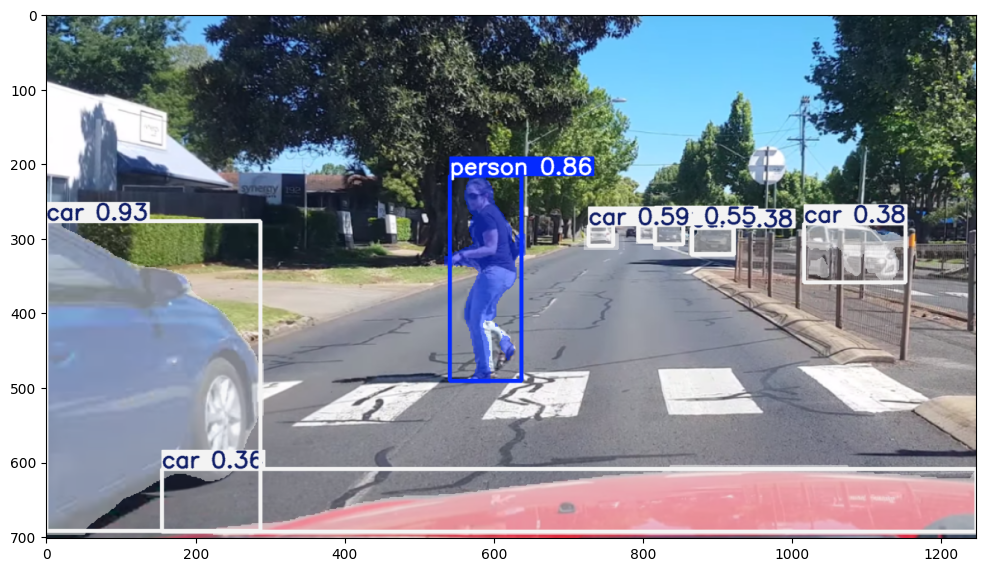

In [4]:
# Load an image
image = cv2.imread('/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/dashcam.png')  # Replace with your image path

# Run inference
results = model(image)  # Model processes the image and predicts masks

# Extract first result
result = results[0]

# Plot results (bounding boxes + masks)
annotated_image = result.plot()  # Draws masks and bounding boxes on the image

# Convert BGR (OpenCV) to RGB for display
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
#plt.axis('off')
plt.show()

### **Step 5:** Understanding the Output

The model can detect 80 different object classes including:

0: person  
1: bicycle  
2: car  
3: motorcycle  
4: airplane  
5: bus  
6: train  
7: truck  
8: boat  
... and many more (traffic lights, fire hydrant, stop sign, etc.)

Each detected object has:

- Bounding box (x1, y1, x2, y2)
- Class label and confidence
- Segmentation mask (polygon or binary mask)

You can access raw segmentation data like this:

In [ ]:
# Access segmentation data
masks = result.masks  # Contains mask information

if masks is not None:
    # Print mask shapes
    print(f"Number of masks: {len(masks)}")
    print(f"Mask data shape: {masks.data.shape}")  # (num_objects, height, width)
    
    # Access boxes and classes
    boxes = result.boxes
    print(f"Boxes: {boxes.xyxy}")  # Bounding box coordinates
    print(f"Classes: {boxes.cls}")  # Class IDs
    print(f"Confidences: {boxes.conf}")  # Confidence scores
    
    # Access mask polygons (for visualization)
    if hasattr(masks, 'xy'): # Check if polygon data is available
        print(f"Mask polygons: {masks.xy}")  # List of polygon points for each mask

Number of masks: 9
Mask data shape: torch.Size([9, 384, 640])
Boxes: tensor([[9.8949e-01, 2.7794e+02, 2.8723e+02, 6.9240e+02],
        [5.4131e+02, 2.1682e+02, 6.3703e+02, 4.9136e+02],
        [7.2708e+02, 2.8382e+02, 7.6036e+02, 3.1043e+02],
        [8.1618e+02, 2.8255e+02, 8.5426e+02, 3.0800e+02],
        [8.6570e+02, 2.8636e+02, 9.2261e+02, 3.2212e+02],
        [1.0160e+03, 2.8013e+02, 1.1526e+03, 3.5969e+02],
        [1.5543e+02, 6.0968e+02, 1.2470e+03, 6.9386e+02],
        [7.9421e+02, 2.8326e+02, 8.1640e+02, 3.0402e+02],
        [8.6643e+02, 2.8698e+02, 9.2131e+02, 3.2174e+02]])
Classes: tensor([2., 0., 2., 2., 2., 2., 2., 2., 2.])
Confidences: tensor([0.9281, 0.8556, 0.5901, 0.5536, 0.3780, 0.3765, 0.3584, 0.3473, 0.3403])
Mask polygons: [array([[          0,      276.68],
       [          0,      695.59],
       [     50.659,      695.59],
       [     50.659,      689.75],
       [     60.402,         680],
       [      62.35,         680],
       [     70.144,      672.21],

### **Step 6:** Visualizing Individual Masks
You can extract and visualize individual segmentation masks:


0: 384x640 1 person, 8 cars, 29.3ms
Speed: 1.2ms preprocess, 29.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


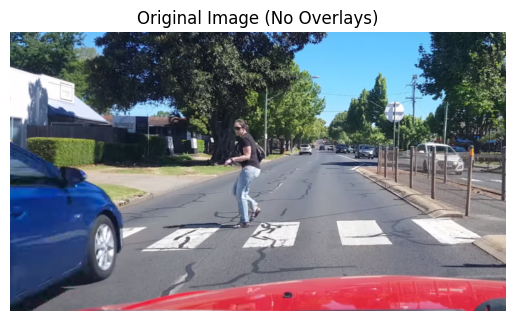

Detected objects: 9


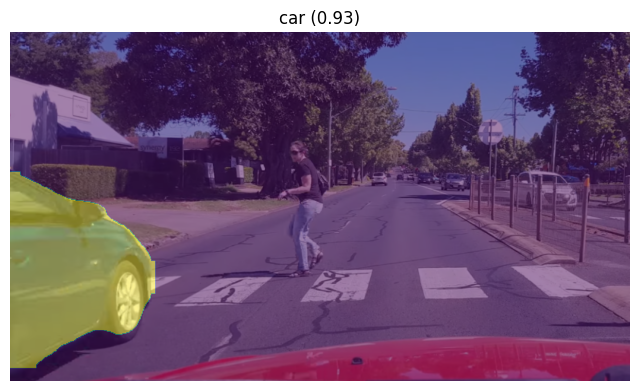

car: 79008 pixels


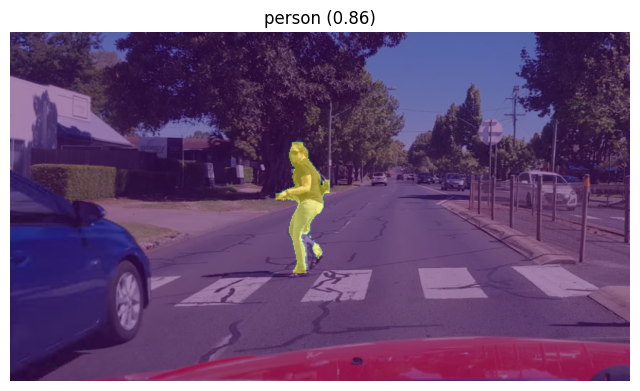

person: 11829 pixels


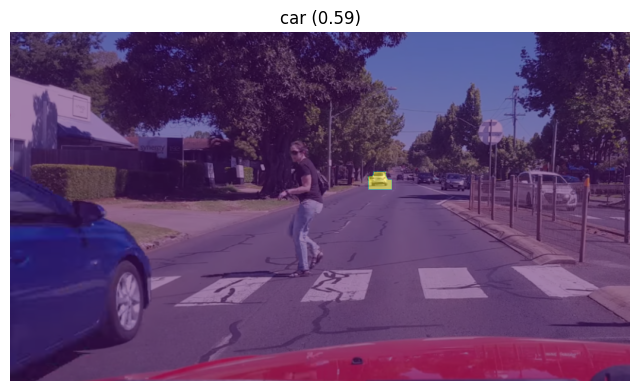

car: 1432 pixels


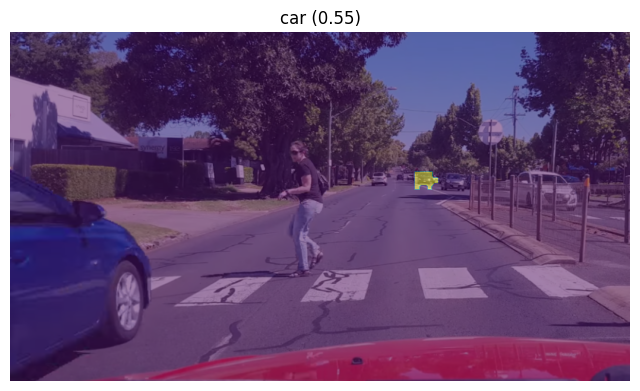

car: 1277 pixels


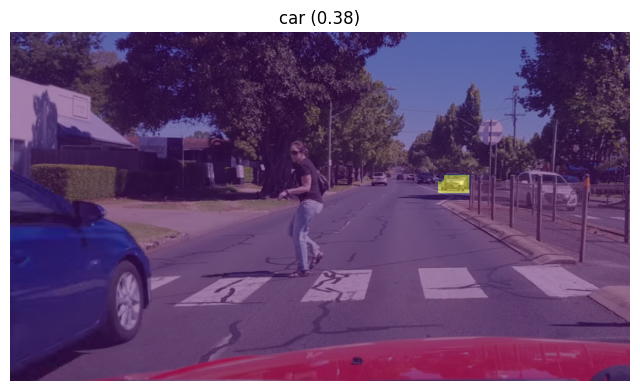

car: 2124 pixels


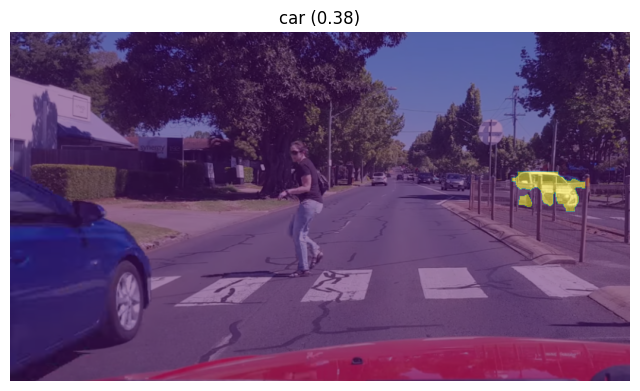

car: 6883 pixels


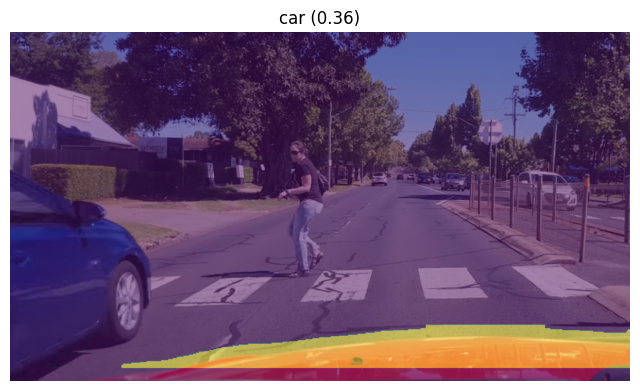

car: 63100 pixels


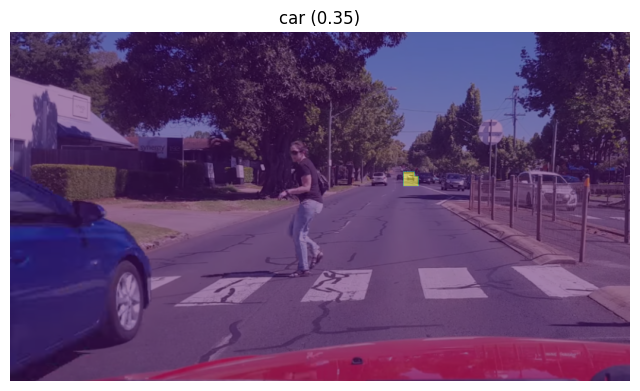

car: 827 pixels


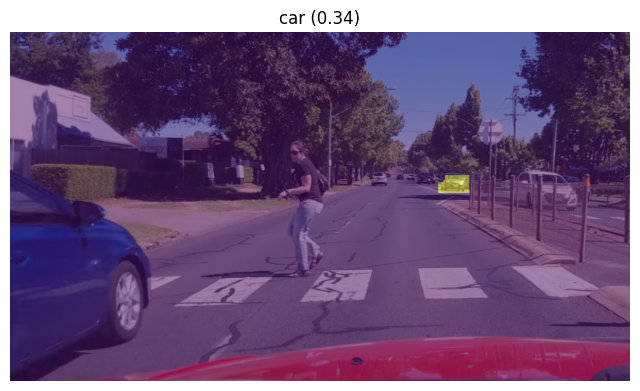

car: 2088 pixels


In [10]:
# Step 1: Load image
image_path = '/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/dashcam.png'  # Path to your image
image = cv2.imread(image_path)  # Read image using OpenCV (BGR format)

# Get original image size (height, width)
h, w = image.shape[:2]

# Step 2: Run YOLO segmentation
result = model(image)[0]  # Run inference and take first result

# Step 3: Show global result (no boxes, no labels, no masks drawn)
img_plot = result.plot(boxes=False, labels=False, masks=False)  # Render clean image
img_plot = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB for matplotlib

# Display image
plt.imshow(img_plot)
plt.axis('off')
plt.title("Original Image (No Overlays)")
plt.show()

# Step 4: Process masks (if any detected)
if result.masks is not None:

    # Extract raw mask data (N, H, W). N = number of detected objects, H and W are YOLO input dimensions (e.g., 640x640).
    masks = result.masks.data.cpu().numpy() # Convert to NumPy array for processing.

    # Extract bounding boxes and class info
    boxes = result.boxes.xyxy.cpu().numpy() # Bounding box coordinates (x1, y1, x2, y2) scaled to YOLO input size 
    classes = result.boxes.cls.cpu().numpy() # Class IDs for each detected object
    confs = result.boxes.conf.cpu().numpy() # Confidence scores for each detected object

    # Get YOLO internal resolution
    mh, mw = masks.shape[1:] # Height and width of YOLO input (e.g., 640x640)

    # Convert original image to RGB once
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert original image to RGB for consistent plotting

    print(f"Detected objects: {len(masks)}") # Print number of detected objects

    # Step 5: Loop over each detected object
    for i, mask in enumerate(masks):

        plt.figure(figsize=(8, 6))  # Create new figure

        # Resize mask to original image size
        mask = cv2.resize(mask, (w, h))  # Match original resolution

        # Binarize mask (clean threshold)
        mask = (mask > 0.5).astype(float) # Convert to binary mask (0 or 1) for better visualization

        # Show original image
        plt.imshow(img_rgb) # Display original image as background

        # Overlay mask with transparency
        plt.imshow(mask, alpha=0.5) # Show mask with 50% transparency

        # Get class name
        label = model.names[int(classes[i])] # Get class name from model's class list using class ID

        # Title with class and confidence
        plt.title(f"{label} ({confs[i]:.2f})")
        plt.axis('off')
        plt.show()

        # Print mask area (number of pixels)
        print(f"{label}: {mask.sum():.0f} pixels")

### **Step 7:** Run Segmentation on Video
We can also process video streams frame-by-frame.

In [ ]:
# Run inference on a video file and save results
video_path = '/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/india_highway.mp4'  # Path to input video
output_path = '/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/annotated_video.mp4'  # Path to save annotated video

model(
    source=video_path,
    save=True,
    project='/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation',
    name='india_highway_annotated'
)  # Runs inference on video and saves annotated output

### **Step 8:** Real-time Webcam Segmentation

In [ ]:
# Run real-time segmentation on webcam
# Press 'q' to quit
model.predict(
    source=0,  # 0 for webcam
    show=True,  # Display the output
    save=False,
    conf=0.5  # Confidence threshold
)

### **Individual Activity**


#### **Activity Recognition using Segmentation**

**Task:** Propose and implement an activity recognition task based on segmentation masks. For example:

- Object **size estimation**: Determine if a detected object is "large" or "small" based on its mask area.
- **Background replacement**: Replace the background of detected persons with a custom image.

**Requirements (5 points total):**

- Clearly explain the selected activity and why it is relevant or useful. Describe the real-world application (e.g., safety monitoring, retail analytics, autonomous systems). Explicitly, **why object detection is insufficient**. (1 point)

- Identify and describe the specific code you implemented or modified - **line by line**. Explain how you use the segmentation masks to perform your activity recognition. (2 points)

- Show your system working in real-time. Deliver a **live webcam demonstration** (pre-recorded videos will not be evaluated). (2 points)

Following you have an easy example for person detection with specific object interaction: Detect if a person is holding a cellphone, carrying a backpack, or wearing a hat. This kind of easy examples where you just compare detected classes will not be graded.

In [ ]:
# Example: Person with cellphone detection using segmentation
def detect_person_with_cellphone():
    model = YOLO('yolo26n-seg.pt')
    cap = cv2.VideoCapture(0)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        results = model(frame)
        result = results[0]
        
        # Check if person and cellphone are both detected
        has_person = False
        has_cellphone = False
        
        if result.boxes is not None:
            classes = result.boxes.cls.cpu().numpy()
            for cls in classes:
                if model.names[int(cls)] == 'person':
                    has_person = True
                if model.names[int(cls)] == 'cell phone':
                    has_cellphone = True
        
        # Display status
        status = "Person with cellphone detected!" if (has_person and has_cellphone) else "No cellphone detected"
        cv2.putText(frame, status, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        # Show annotated frame
        annotated = result.plot()
        cv2.imshow('Segmentation', annotated)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

# Uncomment to run:
detect_person_with_cellphone()

### **Summary:**

You have learned:

- How to use YOLO for instance segmentation
- How to run inference on images and videos
- How to visualize and interpret segmentation masks
- How to access individual masks and bounding boxes
- How to create custom activity recognition using segmentation

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>